# 📦 TurboEnvíos — Diagnóstico estadístico de la operación de última milla

**Análisis de Datos · Estadística descriptiva aplicada**
Dataset: `turboenvios_entregas.csv` · 50.000 entregas · junio 2026

---

## La pregunta de negocio

TurboEnvíos es una empresa de mensajería de última milla. La dirección nos entrega el registro de un mes completo de entregas y nos hace dos preguntas que valen dinero:

> **1. ¿Qué encarece nuestros envíos?** — para saber dónde optimizar el costo.
> **2. ¿Qué enoja a nuestros clientes?** — porque un cliente insatisfecho no vuelve.

Toda la estadística descriptiva existe para responder **tres preguntas sobre un conjunto de datos**: *¿dónde está el centro?*, *¿qué tan dispersos están los valores alrededor de ese centro?* y *¿qué posición ocupa cada dato?*. A esas tres añadiremos una cuarta, la que de verdad genera valor: *¿cómo se relacionan unas variables con otras?*.

Este notebook recorre ese camino **paso a paso**: cada celda de código va precedida de una explicación del concepto, su fórmula y la lectura de negocio del resultado. No buscamos calcular números bonitos, sino **convertir 50.000 filas en decisiones**.

In [9]:
import pandas as pd                     # pandas: trabajar con tablas (DataFrames). Lo renombramos a 'pd' por convención
import numpy as np                      # numpy: cálculo numérico con arrays. Renombrado a 'np' por convención
import matplotlib.pyplot as plt         # matplotlib: librería base para dibujar gráficos. 'plt' es el alias estándar
import seaborn as sns                   # seaborn: gráficos estadísticos más bonitos, construido encima de matplotlib

# --- Estilo visual coherente para todo el informe ---
sns.set_theme(style="whitegrid", font_scale=1.05)  # aplica un tema con rejilla blanca y agranda un 5% el texto
plt.rcParams["figure.figsize"] = (9, 5)            # tamaño por defecto de TODAS las figuras: 9 de ancho x 5 de alto (pulgadas)
plt.rcParams["axes.titlesize"] = 14                # tamaño de letra por defecto del título de cada gráfico
plt.rcParams["axes.titleweight"] = "bold"          # los títulos saldrán en negrita

# Paleta corporativa (naranja = acento, verde = positivo, azul = neutro)
NARANJA, VERDE, AZUL, GRIS = "#d97642", "#3f9d6b", "#3f6f9d", "#8a8a8a"  # guardamos 4 colores en código hexadecimal para reusarlos

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")  # al mostrar números, usar separador de miles y 2 decimales (ej: 8,380.67)
print("Entorno listo · pandas", pd.__version__, "· numpy", np.__version__)  # confirma que cargó e imprime las versiones instaladas


Entorno listo · pandas 3.0.3 · numpy 2.5.0


In [10]:
# read_csv: lee el archivo CSV y lo convierte en un DataFrame (tabla). encoding="latin-1" para que los acentos no se rompan.
# parse_dates=["fecha"]: le dice a pandas que la columna 'fecha' son fechas reales, no texto.
df = pd.read_csv("turboenvios_entregas.csv", parse_dates=["fecha"])

# df.shape devuelve (nº de filas, nº de columnas). [0] = filas, [1] = columnas. El :, pone separador de miles.
print(f"El dataset tiene {df.shape[0]:,} casos (entregas) y {df.shape[1]} variables (columnas)\n")
df.head()   # muestra las primeras 5 filas para echar un vistazo a cómo son los datos


El dataset tiene 50,000 casos (entregas) y 9 variables (columnas)



,pedido_id,fecha,zona,tipo_servicio,distancia_km,peso_kg,tiempo_entrega_min,costo_envio,calificacion_cliente
0,1,2026-06-07,Residencial,Estándar,13.40,0.96,89.50,"12,157.00",1.00
1,2,2026-06-20,Comercial,Estándar,7.30,5.07,57.10,"10,426.00",2.00
2,3,2026-06-29,Comercial,Estándar,2.25,1.49,43.00,"4,460.00",5.00
3,4,2026-06-15,Centro,Express,3.74,5.49,41.40,"11,186.00",2.00
4,5,2026-06-11,Periferia,Express,5.15,3.09,32.60,"9,907.00",5.00


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   pedido_id             50000 non-null  int64         
 1   fecha                 50000 non-null  datetime64[us]
 2   zona                  50000 non-null  str           
 3   tipo_servicio         50000 non-null  str           
 4   distancia_km          50000 non-null  float64       
 5   peso_kg               50000 non-null  float64       
 6   tiempo_entrega_min    50000 non-null  float64       
 7   costo_envio           50000 non-null  float64       
 8   calificacion_cliente  49500 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(2)
memory usage: 3.4 MB


In [12]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]
print("Valores faltantes por columnas")
print(faltantes)
# .isnull().mean() 
print(f"\n{df['calificacion_cliente'].isnull().mean():.1%} de las entregas no tienen calificacion de cliente")

Valores faltantes por columnas
calificacion_cliente    500
dtype: int64

1.0% de las entregas no tienen calificacion de cliente


In [ ]:
# Tabla de frecuencia de la variable 'zona'
frec = df["zona"].value_counts()                        # value_counts() cuenta cuántas veces aparece cada zona (frecuencia absoluta)
frec_rel = df["zona"].value_counts(normalize=True)*100  # normalize=True devuelve proporciones (0-1); *100 las pasa a porcentaje

tabla_zona = pd.DataFrame({                              # construimos una tabla nueva juntando las tres columnas calculadas
    "Frec. absoluta": frec,                             # el conteo crudo
    "Frec. relativa (%)": frec_rel.round(1),            # el porcentaje, redondeado a 1 decimal
    "Frec. acumulada (%)": frec_rel.cumsum().round(1),  # cumsum() suma acumulando fila a fila: 28.3, luego 28.3+27.7, etc.
})
tabla_zona           

,Frec. absoluta,Frec. relativa (%),Frec. acumulada (%)
zona,,,
Periferia,14171,28.30,28.30
Centro,13870,27.70,56.10
Comercial,8090,16.20,72.30
Industrial,7767,15.50,87.80
Residencial,6102,12.20,100.00


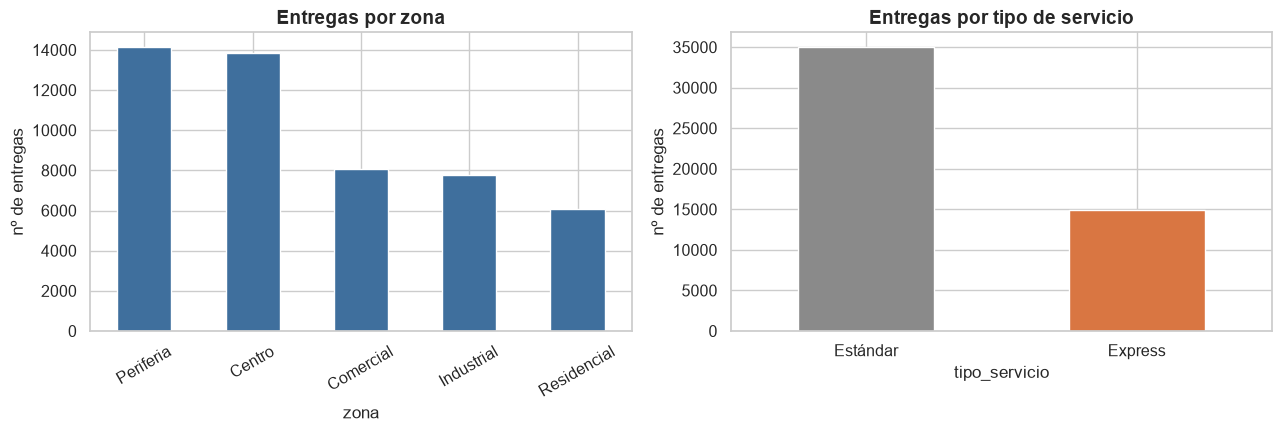

In [24]:
# Visualizamos las dos variables cualitativas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["zona"].value_counts().plot(kind="bar", ax=axes[0], color=AZUL)
axes[0].set_title("Entregas por zona")
axes[0].set_ylabel("nº de entregas")
axes[0].tick_params(axis="x", rotation=30)

df["tipo_servicio"].value_counts().plot(kind="bar", ax=axes[1], color=[GRIS, NARANJA])
axes[1].set_title("Entregas por tipo de servicio")
axes[1].set_ylabel("nº de entregas")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Lectura: Periferia y Centro concentran más de la mitad del volumen, son el corazón operativo, donde cualquier mejora tiene mas impacto, es estandar domina 70% frente a express 30%.